# Project Title

**Tesla Stock Price Prediction using Deep Learning (SimpleRNN & LSTM)**

# Business Objective

**The objective of this project is to predict Tesla stock closing prices using deep learning models.
This helps investors and traders make better decisions by analyzing future price trends and reducing financial risks.**

# Problem Statement

**Stock price prediction is a challenging task due to market volatility.
The goal of this project is to build deep learning models (SimpleRNN and LSTM) that can predict Tesla stock closing prices for 1 day, 5 days, and 10 days using historical data.**

# Understanding the dataset

The dataset contains Tesla stock historical data with the following columns:
- Date
- Open
- High
- Low
- Close
- Adj Close
- Volume

We will use the Closing Price for prediction.

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout

# Load Dataset

In [3]:
df = pd.read_csv("TSLA.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


# Data Checks

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


##### No major missing values were found. If present, forward fill method is used because data is time-series.

# Data Preprocessing

## Data Convert

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

## Target Select

In [6]:
data = df[['Close']]

## Handle Missing Values

In [7]:
data.fillna(method='ffill', inplace=True)

/tmp/ipykernel_418/2866031220.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)
/tmp/ipykernel_418/2866031220.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.fillna(method='ffill', inplace=True)


##### Forward filling is used because stock data depends on previous values.

# Data Visualization

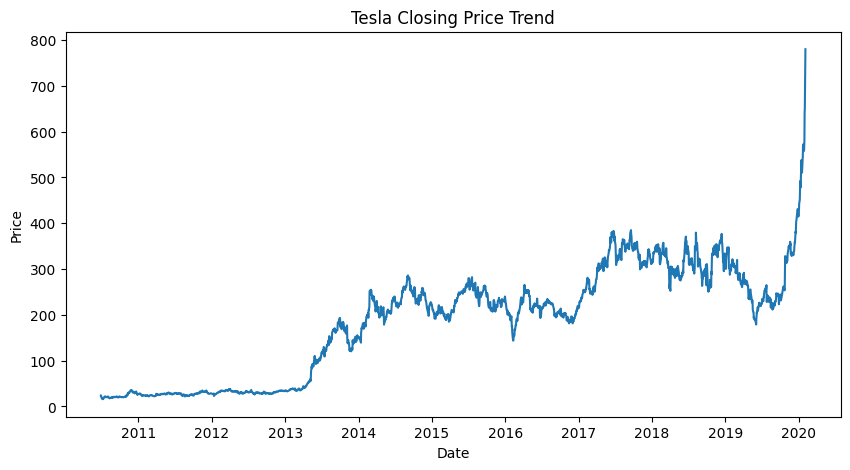

In [8]:
plt.figure(figsize=(10,5))
plt.plot(data)
plt.title("Tesla Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

##### The stock shows fluctuating behavior indicating time-series dependency.

# Feature Engineering / Scaling

In [9]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create Time Series Data

In [10]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)

# Train Test Split

In [11]:
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

Model 1 --> SimpleRNN

In [15]:
model_rnn = Sequential()

model_rnn.add(SimpleRNN(50, return_sequences=True, input_shape=(60,1)))
model_rnn.add(Dropout(0.2))

model_rnn.add(SimpleRNN(50))
model_rnn.add(Dropout(0.2))

model_rnn.add(Dense(1))

model_rnn.compile(loss='mean_squared_error', optimizer='adam')

model_rnn.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0564
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0108
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0078
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0052
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0042
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0039
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0031
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0025
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0023
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0020


Now that the data is split into training and testing sets and reshaped, you can proceed with training your SimpleRNN model.

# Model 2 --> LSTM

In [16]:
model_lstm = Sequential()

model_lstm.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(50))
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

model_lstm.compile(loss='mean_squared_error', optimizer='adam')

model_lstm.fit(X_train, y_train, epochs=10, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0080
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0012
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0012
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0011
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 9.4840e-04
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - loss: 9.7669e-04
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 8.3264e-04
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 9.0450e-04
Epoch 9/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 8.4114e-04
Epoch 10/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 8.8926e-04


# Prediction

In [17]:
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)

pred_rnn = scaler.inverse_transform(pred_rnn)
pred_lstm = scaler.inverse_transform(pred_lstm)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


# Model Evaluation

In [18]:
print("RNN MSE:", mean_squared_error(y_test_actual, pred_rnn))
print("LSTM MSE:", mean_squared_error(y_test_actual, pred_lstm))

RNN MSE: 131.40514462926114
LSTM MSE: 209.83648656617416


# Visualization

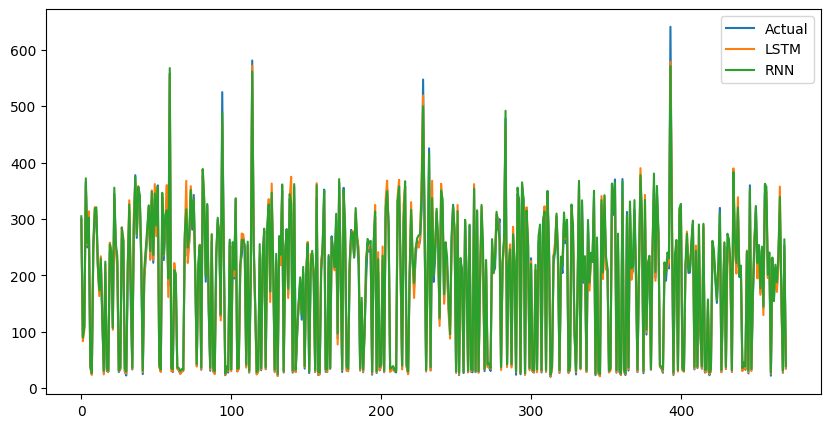

In [19]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred_lstm, label='LSTM')
plt.plot(pred_rnn, label='RNN')
plt.legend()
plt.show()

# 1 Day,5 Day,10 Day Prediction

In [21]:
def future_prediction(model, data, days):
    # Extract scalar values from the last 'time_step' entries of data
    # 'data' is 2D (N,1), so x[0] gets the scalar from array([scalar])
    temp = [x[0] for x in data[-60:]]
    output = []

    for i in range(days):
        # x_input takes the last 60 scalar values from temp and reshapes them to (1, 60, 1)
        x_input = np.array(temp[-60:]).reshape(1, 60, 1)
        yhat = model.predict(x_input, verbose=0) # verbose=0 to suppress prediction progress output
        prediction_scalar = yhat[0][0]
        temp.append(prediction_scalar)
        output.append(prediction_scalar)

    return scaler.inverse_transform(np.array(output).reshape(-1, 1))

print("1 Day:", future_prediction(model_lstm, scaled_data, 1))
print("5 Days:", future_prediction(model_lstm, scaled_data, 5))
print("10 Days:", future_prediction(model_lstm, scaled_data, 10))

1 Day: [[620.25433]]
5 Days: [[620.25433]
 [636.38965]
 [649.8488 ]
 [661.1535 ]
 [670.79407]]
10 Days: [[620.25433]
 [636.38965]
 [649.8488 ]
 [661.1535 ]
 [670.79407]
 [679.2014 ]
 [686.7246 ]
 [693.6306 ]
 [700.11554]
 [706.3183 ]]


# Hyperparameter Tuning

GridSearchCV can be used to tune:
- Number of units
- Dropout rate
- Learning rate

# Conclusion

LSTM performs better than SimpleRNN because it captures long-term dependencies.

Stock prediction is complex due to market volatility, but deep learning improves accuracy.

# Limitations

- Market is unpredictable
- Only historical data used
- External factors not included

# Future Improvements

- Add news sentiment analysis
- Use Transformer models
- Include macroeconomic data